# <b><i><u>mxmh_survey_results</u> ----</b></i>

In [1]:
# IGNORE WARNING --

import warnings
warnings.filterwarnings("ignore")


# IMPORTING ALL NECESSARY LIBRARIES --

from pathlib import Path
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# xgboost
from xgboost import XGBClassifier

# saving model
import joblib

print("ALL NECESSARY LIBRARIES ARE IMPORTED SUCESSFULLY:")
print("🎉🎉🎉🎉")

ALL NECESSARY LIBRARIES ARE IMPORTED SUCESSFULLY:
🎉🎉🎉🎉


In [2]:
# current notebook location = notebooks/model_building
CURRENT_DIR = Path.cwd()

# notebooks folder
NOTEBOOKS_DIR = CURRENT_DIR.parent

# notebooks/preprocessed
PREPROCESSED_DIR = NOTEBOOKS_DIR / "preprocessed"

# notebooks/models
MODELS_DIR = NOTEBOOKS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Current Dir:", CURRENT_DIR)
print("Preprocessed Dir:", PREPROCESSED_DIR)
print("Models Dir:", MODELS_DIR)

Current Dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\mxmh_survey_results
Preprocessed Dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\preprocessed
Models Dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\models


In [3]:
# LOADING DATASET --

mxmh_path = PREPROCESSED_DIR / "mxmh_feature_engineered.csv"

df = pd.read_csv(mxmh_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (736, 42)


,age,streaming_service,hours_per_day,while_working,instrumentalist,composer,fav_genre,exploratory,foreign_languages,bpm,...,mental_health_score,music_engagement_score,focus_listening_score,high_energy_score,calm_music_score,intense_music_score,genre_diversity_score,bpm_zone,mental_health_band,listening_band
0,18.0,spotify,3.0,1,1,1,latin,1,1,156.0,...,1.00,6.0,5,9,2,3,21,high_bpm,low,moderate_listener
1,63.0,pandora,1.5,1,0,0,rock,1,0,119.0,...,3.00,2.5,5,4,7,4,22,medium_bpm,moderate,low_listener
2,18.0,spotify,4.0,0,0,0,video game music,0,1,132.0,...,6.50,4.0,5,6,3,4,18,high_bpm,high,moderate_listener
3,61.0,youtube music,2.5,1,0,1,jazz,1,1,84.0,...,5.50,4.5,5,2,8,0,19,low_bpm,moderate,moderate_listener
4,18.0,spotify,4.0,1,0,0,r&b,1,0,107.0,...,5.75,5.0,4,9,2,3,21,medium_bpm,moderate,moderate_listener


In [4]:
# TARGET DISTRIBUTION --

print(df["music_effects"].value_counts(dropna=False))
print("\nNormalized distribution:")
print(df["music_effects"].value_counts(normalize=True))

music_effects
improve      550
no effect    169
worsen        17
Name: count, dtype: int64

Normalized distribution:
music_effects
improve      0.747283
no effect    0.229620
worsen       0.023098
Name: proportion, dtype: float64


In [5]:
# DROPPING UNNECESSARY COLUMNS --

drop_cols = []

possible_drop = [
    "timestamp",
    "permissions"
]

for col in possible_drop:
    if col in df.columns:
        drop_cols.append(col)

if drop_cols:
    df = df.drop(columns=drop_cols)

print("Dropped columns:", drop_cols)
print("New shape:", df.shape)

Dropped columns: []
New shape: (736, 42)


In [6]:
df["music_effects"] = df["music_effects"].astype(str).str.strip().str.lower()

print(df["music_effects"].value_counts())

music_effects
improve      550
no effect    169
worsen        17
Name: count, dtype: int64


In [7]:
# TARGET CLASSES --

valid_classes = ["improve", "no effect", "worsen"]

df = df[df["music_effects"].isin(valid_classes)].copy()

print("Shape after target cleaning:", df.shape)
print(df["music_effects"].value_counts())

Shape after target cleaning: (736, 42)
music_effects
improve      550
no effect    169
worsen        17
Name: count, dtype: int64


In [8]:
# ENCODE TARGET --

target_map = {
    "worsen": 0,
    "no effect": 1,
    "improve": 2
}

df["music_effects"] = df["music_effects"].map(target_map)

print(df["music_effects"].value_counts())

music_effects
2    550
1    169
0     17
Name: count, dtype: int64


In [9]:
# X & Y  --
 
TARGET = "music_effects"

drop_cols = [
    "music_effects",        # target
    "music_effects_label"   # agar encoded target duplicate hai
]

X = df.drop(columns=drop_cols, errors="ignore")
y = df[TARGET]

In [10]:
non_numeric_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Non-numeric columns:", non_numeric_cols)

Non-numeric columns: ['streaming_service', 'fav_genre', 'bpm_zone', 'mental_health_band', 'listening_band']


In [11]:
if len(non_numeric_cols) > 0:
    X = pd.get_dummies(X, columns=non_numeric_cols, drop_first=True)

print("Final X shape after encoding:", X.shape)

Final X shape after encoding: (736, 61)


# <B><U><I>MODEL BUILDING</U> --</B></I>

In [12]:
# TRAIN TEST SPLIT --

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (588, 61)
X_test : (148, 61)
y_train: (588,)
y_test : (148,)


# <B><I><U>MODEL 1</U> ----</B></I>

In [13]:
# LOGISTIC REGRESSION --

log_reg = LogisticRegression(
    max_iter=3000,
    random_state=42
)

log_reg.fit(X_train, y_train)

log_pred = log_reg.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred, average="weighted")

print("Logistic Regression Accuracy:", round(log_acc, 4))
print("Logistic Regression Weighted F1:", round(log_f1, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7095
Logistic Regression Weighted F1: 0.654

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.33      0.09      0.14        34
           2       0.76      0.92      0.83       111

    accuracy                           0.71       148
   macro avg       0.36      0.34      0.32       148
weighted avg       0.64      0.71      0.65       148



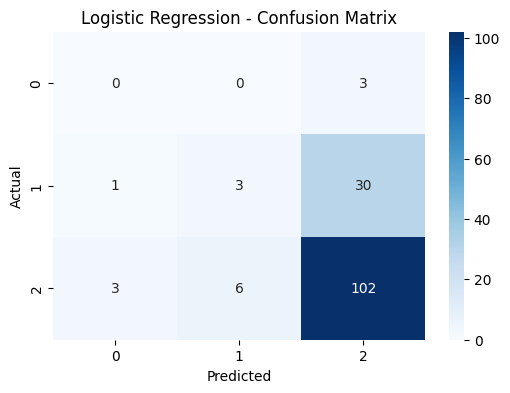

In [14]:
# CONFUSION MATRIX --

cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# <B><U><I>MODEL 2</U> ----</B></I>

In [15]:
# RANDOM FOREST --

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

print("Random Forest Accuracy:", round(rf_acc, 4))
print("Random Forest Weighted F1:", round(rf_f1, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.75
Random Forest Weighted F1: 0.6429

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00        34
           2       0.75      1.00      0.86       111

    accuracy                           0.75       148
   macro avg       0.25      0.33      0.29       148
weighted avg       0.56      0.75      0.64       148



# <B><I><U>MODEL 3</U> ----</B></I>

In [16]:
# XG-BOOST --

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")

print("XGBoost Accuracy:", round(xgb_acc, 4))
print("XGBoost Weighted F1:", round(xgb_f1, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.7635
XGBoost Weighted F1: 0.7148

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.54      0.21      0.30        34
           2       0.79      0.95      0.86       111

    accuracy                           0.76       148
   macro avg       0.44      0.39      0.39       148
weighted avg       0.71      0.76      0.71       148



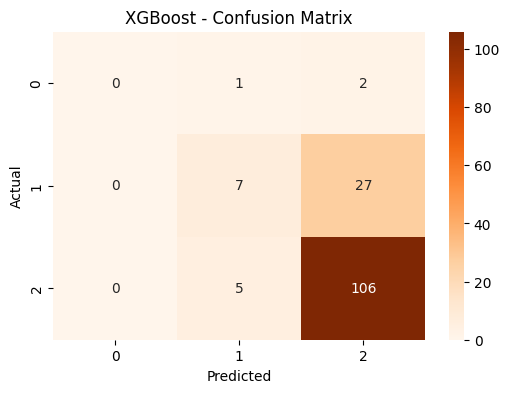

In [17]:
# CONFUSION MATRIX --

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [log_acc, rf_acc, xgb_acc],
    "Weighted_F1": [log_f1, rf_f1, xgb_f1]
})

results = results.sort_values(by=["Weighted_F1", "Accuracy"], ascending=False).reset_index(drop=True)
results

,Model,Accuracy,Weighted_F1
0,XGBoost,0.763514,0.714772
1,Logistic Regression,0.709459,0.654007
2,Random Forest,0.750000,0.642857


In [19]:
# CROSS VALIDATION --

cv_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Cross-validation weighted F1 scores:", cv_scores)
print("Mean CV weighted F1:", cv_scores.mean())
print("Std CV weighted F1:", cv_scores.std())

Cross-validation weighted F1 scores: [0.62712105 0.64308679 0.66940707 0.6490204  0.6185838 ]
Mean CV weighted F1: 0.6414438222368772
Std CV weighted F1: 0.017718746080296874


In [20]:
print("Total features used:", len(X.columns))
print("\nFeature columns:\n")
for col in X.columns:
    print(col)

Total features used: 61

Feature columns:

age
hours_per_day
while_working
instrumentalist
composer
exploratory
foreign_languages
bpm
freq_classical
freq_country
freq_edm
freq_folk
freq_gospel
freq_hip_hop
freq_jazz
freq_k_pop
freq_latin
freq_lofi
freq_metal
freq_pop
freq_rnb
freq_rap
freq_rock
freq_vgm
anxiety
depression
insomnia
ocd
mental_health_score
music_engagement_score
focus_listening_score
high_energy_score
calm_music_score
intense_music_score
genre_diversity_score
streaming_service_i do not use a streaming service.
streaming_service_other streaming service
streaming_service_pandora
streaming_service_spotify
streaming_service_youtube music
fav_genre_country
fav_genre_edm
fav_genre_folk
fav_genre_gospel
fav_genre_hip hop
fav_genre_jazz
fav_genre_k pop
fav_genre_latin
fav_genre_lofi
fav_genre_metal
fav_genre_pop
fav_genre_r&b
fav_genre_rap
fav_genre_rock
fav_genre_video game music
bpm_zone_low_bpm
bpm_zone_medium_bpm
mental_health_band_low
mental_health_band_moderate
listening_b

In [21]:
temp_df = X.copy()
temp_df["music_effects"] = y.values

corr_with_target = temp_df.corr(numeric_only=True)["music_effects"].sort_values(ascending=False)

print(corr_with_target.head(30))
print("\nMost negative correlations:\n")
print(corr_with_target.tail(20))

music_effects                       1.000000
while_working                       0.165183
exploratory                         0.144211
freq_rnb                            0.120913
instrumentalist                     0.098826
genre_diversity_score               0.098299
freq_gospel                         0.091856
anxiety                             0.087400
composer                            0.085482
music_engagement_score              0.085427
freq_country                        0.077384
high_energy_score                   0.076942
fav_genre_hip hop                   0.072781
streaming_service_pandora           0.068507
freq_k_pop                          0.066196
freq_lofi                           0.066121
fav_genre_lofi                      0.065274
freq_jazz                           0.062851
freq_pop                            0.062598
freq_edm                            0.054078
freq_hip_hop                        0.053301
fav_genre_edm                       0.052727
calm_music

In [22]:
# ============================================================
# MENTAL HEALTH COMBINED FEATURES
# ============================================================

df["mental_health_score"] = (
    df["anxiety"] +
    df["depression"] +
    df["insomnia"] +
    df["ocd"]
) / 4

df["internal_distress_score"] = (
    df["anxiety"] +
    df["depression"] +
    df["ocd"]
) / 3

df["sleep_disturbance_score"] = df["insomnia"]

# optional severity band
def mental_band(score):
    if score < 3:
        return "low"
    elif score < 6:
        return "moderate"
    else:
        return "high"

df["mental_health_band"] = df["mental_health_score"].apply(mental_band)

In [23]:
df = pd.get_dummies(df, columns=["mental_health_band"], drop_first=False)

In [24]:
import joblib
from pathlib import Path

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["music_effects_label"] = label_encoder.fit_transform(df["music_effects"])
# ============================================================
# SAVE DIRECTORY
# notebooks/models
# ============================================================

CURRENT_DIR = Path.cwd()                 # notebooks/model_building folder ke andar
NOTEBOOKS_DIR = CURRENT_DIR.parent       # notebooks
MODELS_DIR = NOTEBOOKS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# SAVE BEST MODEL = XGBOOST
# ============================================================

joblib.dump(xgb_model, MODELS_DIR / "mxmh_music_effects_xgb.pkl")

# feature column order save
joblib.dump(list(X_train.columns), MODELS_DIR / "mxmh_music_effects_features.pkl")

# label encoder save
joblib.dump(label_encoder, MODELS_DIR / "mxmh_music_effects_label_encoder.pkl")

print("MXMH XGBoost model saved successfully")
print("Saved model:", MODELS_DIR / "mxmh_music_effects_xgb.pkl")
print("Saved features:", MODELS_DIR / "mxmh_music_effects_features.pkl")
print("Saved label encoder:", MODELS_DIR / "mxmh_music_effects_label_encoder.pkl")

MXMH XGBoost model saved successfully
Saved model: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\models\mxmh_music_effects_xgb.pkl
Saved features: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\models\mxmh_music_effects_features.pkl
Saved label encoder: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\models\mxmh_music_effects_label_encoder.pkl


In [25]:
print(type(xgb_model))

print(xgb_model)

print(hasattr(xgb_model, "predict_proba"))

<class 'xgboost.sklearn.XGBClassifier'>
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)
True


In [26]:
pred = xgb_model.predict(X_test)

print(pred[:10])
print(pred.min())
print(pred.max())

[2 2 2 2 2 2 2 2 2 2]
1
2


In [27]:
print(df[y].head())

print(df[y].dtype)

print(df[y].value_counts().head(20))

KeyError: "None of [Index([2, 2, 1, 2, 2, 2, 2, 2, 2, 2,\n       ...\n       2, 1, 2, 2, 2, 2, 2, 2, 2, 2],\n      dtype='int64', length=736)] are in the [columns]"